<a href="https://colab.research.google.com/github/alizasultanaesd-png/skill-morph-work/blob/main/GEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install xee geemap pymannkendall
!pip install earthengine-api geemap
!pip install xarray netCDF4 matplotlib
!pip install cartopy
import ee
import geemap as gee
import xarray as xr
import numpy as np
import pymannkendall as mk
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc
import sys
import geopandas as gpd
import seaborn as sns

In [5]:
# Authenticate
ee.Authenticate()

# Initialize with your Project ID
ee.Initialize(project='climate-data-analysis-01')

# ERA5 dataset (last 40 years)
collection = ee.ImageCollection("ECMWF/ERA5/MONTHLY") \
    .select('mean_2m_air_temperature') \
    .filterDate('1975-01-01', '2025-12-31')

print(collection.size().getInfo())


498


In [3]:
!pip install cdsapi
!pip install xarray netCDF4
!pip install netCDF4 h5netcdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 76.1 MB/s eta 0:00:00


url: https://cds.climate.copernicus.eu/api
key: 0f1af533-97e4-47fd-afaa-defb58d4affe

**CDS API key setting**

In [6]:
import cdsapi
c = cdsapi.Client(url='https://cds.climate.copernicus.eu/api',
                  key='0f1af533-97e4-47fd-afaa-defb58d4affe')


In [7]:
%%writefile /root/.cdsapirc
url: https://cds.climate.copernicus.eu/api
key: 0f1af533-97e4-47fd-afaa-defb58d4affe


Overwriting /root/.cdsapirc


**46 years DATA download**

In [8]:
import cdsapi
import xarray as xr
import os
import time
import zipfile

c = cdsapi.Client() # CDS API client

def download_chunk(start_year, end_year, prefix, max_retries=3):
    """Download ERA5 monthly means chunk and retry if file corrupt/incomplete"""
    filename = f"{prefix}_{start_year}_{end_year}.zip"
    for attempt in range(max_retries):
        try:
            print(f"Downloading {start_year}-{end_year} → {filename} (Attempt {attempt+1})")
            c.retrieve(
                'reanalysis-era5-single-levels-monthly-means',
                {
                    'product_type': 'monthly_averaged_reanalysis',
                    'time': '00:00',
                    'variable': [
                        '2m_temperature',
                        '2m_dewpoint_temperature',
                        'total_precipitation',
                        'surface_pressure',
                        'mean_sea_level_pressure',
                        'surface_solar_radiation_downwards',
                        'instantaneous_10m_wind_gust'
                    ],
                    'year': [str(y) for y in range(start_year, end_year+1)],
                    'month': [str(m).zfill(2) for m in range(1,13)],
                    'format': 'netcdf',
                    'area': [29, 85, 19, 95]  # Bangladesh bounding box
                },
                filename
            )
            # Extract all .nc files with unique names
            if zipfile.is_zipfile(filename):
                with zipfile.ZipFile(filename, 'r') as zip_ref:
                    zip_ref.extractall("./")
                    extracted_files = []
                    for f in zip_ref.namelist():
                        if f.endswith(".nc"):
                            new_name = f"{prefix}_{start_year}_{end_year}_{f}"
                            os.rename(f, new_name)
                            extracted_files.append(new_name)
                            print(f"✅ Extracted {f} to {new_name}")
                return extracted_files
        except Exception as e:
            print(f"Error: {e}, retrying...")
        time.sleep(5)
    raise RuntimeError(f"❌ Failed to download {filename} after {max_retries} attempts")

# Download chunks
files_1 = download_chunk(1979, 1990, "era5_bangladesh")
files_2 = download_chunk(1991, 2005, "era5_bangladesh")
files_3 = download_chunk(2006, 2025, "era5_bangladesh")

# Merge all extracted files
datasets = []
for f in files_1 + files_2 + files_3:
    ds = xr.open_dataset(f, engine="netcdf4")
    datasets.append(ds)

combined = xr.merge(datasets, compat="override", join="outer")

# Save final dataset safely
final_file = "era5_monthly_bangladesh_1979_2025.nc"
if os.path.exists(final_file):
    os.remove(final_file)

combined.to_netcdf(final_file, mode="w")

print("🎉 Final dataset ready:", final_file)

# Reopen and check variables
ds_final = xr.open_dataset(final_file, mode="r", engine="netcdf4")
print("✅ All variables:", list(ds_final.data_vars))


2026-06-07 01:02:06,551 INFO Request ID is 492a390a-171e-4f8b-82f0-73d3d43758c9
INFO:ecmwf.datastores.legacy_client:Request ID is 492a390a-171e-4f8b-82f0-73d3d43758c9
2026-06-07 01:02:06,613 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-06-07 01:02:39,209 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-06-07 01:02:56,352 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


82d2f05b28dd11a7d8706e9e14a6e9a.zip:   0%|          | 0.00/2.93M [00:00<?, ?B/s]

2026-06-07 01:03:02,255 INFO Request ID is 1a5c42c7-62da-4349-8f82-76668fafb070
INFO:ecmwf.datastores.legacy_client:Request ID is 1a5c42c7-62da-4349-8f82-76668fafb070


✅ Extracted data_stream-moda_stepType-avgua.nc to era5_bangladesh_1979_1990_data_stream-moda_stepType-avgua.nc
✅ Extracted data_stream-moda_stepType-avgad.nc to era5_bangladesh_1979_1990_data_stream-moda_stepType-avgad.nc
✅ Extracted data_stream-moda_stepType-avgid.nc to era5_bangladesh_1979_1990_data_stream-moda_stepType-avgid.nc


2026-06-07 01:03:02,299 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-06-07 01:04:21,799 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


30e2b4d7c846b52de8a19193be3144c5.zip:   0%|          | 0.00/3.62M [00:00<?, ?B/s]

✅ Extracted data_stream-moda_stepType-avgua.nc to era5_bangladesh_1991_2005_data_stream-moda_stepType-avgua.nc
✅ Extracted data_stream-moda_stepType-avgad.nc to era5_bangladesh_1991_2005_data_stream-moda_stepType-avgad.nc
✅ Extracted data_stream-moda_stepType-avgid.nc to era5_bangladesh_1991_2005_data_stream-moda_stepType-avgid.nc


2026-06-07 01:04:23,012 INFO Request ID is 81bf76aa-1a11-47fa-a3c3-5d0ac1072d1e
INFO:ecmwf.datastores.legacy_client:Request ID is 81bf76aa-1a11-47fa-a3c3-5d0ac1072d1e
2026-06-07 01:04:23,070 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-06-07 01:04:32,123 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-06-07 01:04:37,240 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


ff37b5b6e33979cced2478d73f2252c2.zip:   0%|          | 0.00/4.79M [00:00<?, ?B/s]

✅ Extracted data_stream-moda_stepType-avgua.nc to era5_bangladesh_2006_2025_data_stream-moda_stepType-avgua.nc
✅ Extracted data_stream-moda_stepType-avgad.nc to era5_bangladesh_2006_2025_data_stream-moda_stepType-avgad.nc
✅ Extracted data_stream-moda_stepType-avgid.nc to era5_bangladesh_2006_2025_data_stream-moda_stepType-avgid.nc
🎉 Final dataset ready: era5_monthly_bangladesh_1979_2025.nc
✅ All variables: ['t2m', 'd2m', 'sp', 'msl', 'tp', 'ssrd', 'i10fg']


**Mount drive**

In [65]:
#from google.colab import drive
#drive.mount('/content/drive')

from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'1979_1990 data_stream-moda_stepType-avgad.nc'
'1979_1990 data_stream-moda_stepType-avgid.nc'
'1979_1990 data_stream-moda_stepType-avgua.nc'
'1991_2005 data_stream-moda_stepType-avgad.nc'
'1991_2005 data_stream-moda_stepType-avgid.nc'
'1991_2005 data_stream-moda_stepType-avgua (1).nc'
'1991_2005 data_stream-moda_stepType-avgua.nc'
'2006_2025 data_stream-moda_stepType-avgad.nc'
'2006_2025 data_stream-moda_stepType-avgid.nc'
'2006_2025 data_stream-moda_stepType-avgua.nc'
'Climate trends and hazard hotspots in southwest (peri‑urban) Bangladesh: recent evidence and gaps.gdoc'
'Colab Notebooks'
'colab trend'
 data
 data_stream-oper_stepType-instant.nc
 diabetes.csv
'era5 analysis.gdoc'
 era5_monthly_bangladesh_1979_2025.nc
 Housing.csv
'trend analysis methodology.gdoc'


**# প্রতি বছরের total precipitation (mm)
yearly_precip = ds_mean.tp.resample(time="1Y").sum() * 1000**

1979–1990 years: 1979-01-01T06:00:00.000000000 to 1990-12-01T06:00:00.000000000
1991–2005 years: 1991-01-01T06:00:00.000000000 to 2005-12-01T06:00:00.000000000
2006–2025 years: 2006-01-01T06:00:00.000000000 to 2025-12-01T06:00:00.000000000


/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/usr/local

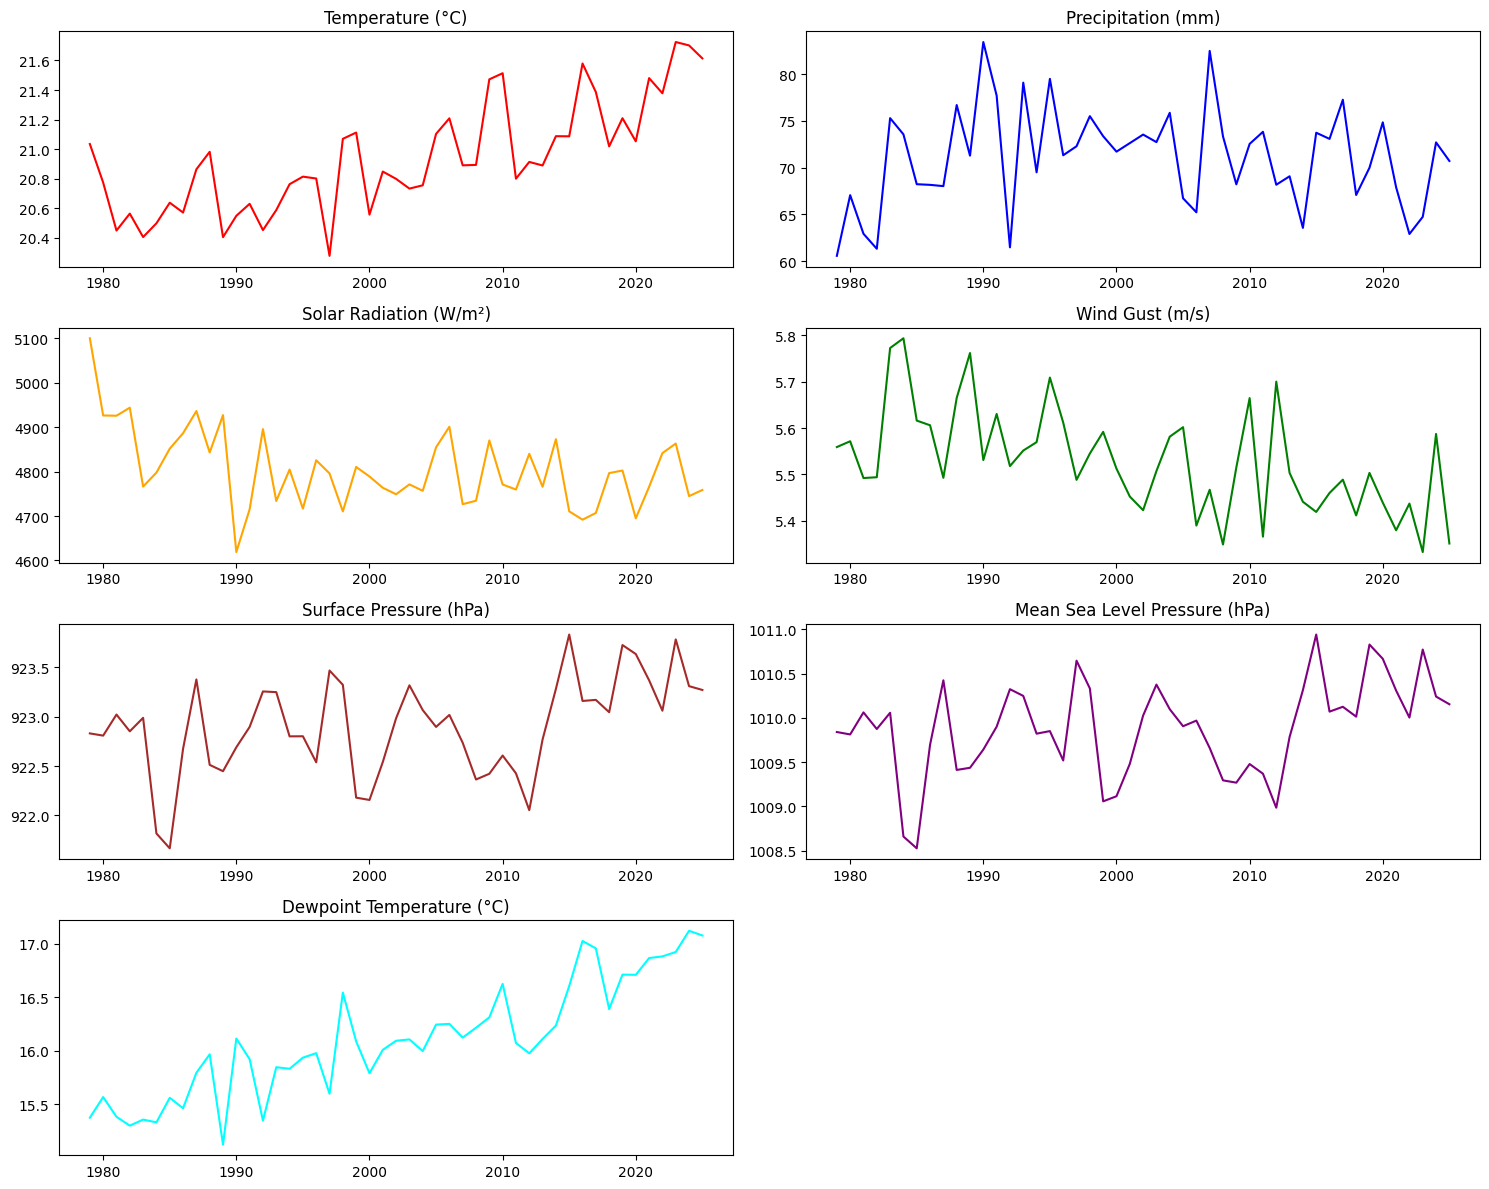

In [35]:
import xarray as xr

#1 Load NetCDF files separately
# 1979–1990
ds_precip_79_90 = xr.open_dataset("/content/drive/MyDrive/1979_1990 data_stream-moda_stepType-avgad.nc")
ds_wind_79_90   = xr.open_dataset("/content/drive/MyDrive/1979_1990 data_stream-moda_stepType-avgid.nc")
ds_temp_79_90   = xr.open_dataset("/content/drive/MyDrive/1979_1990 data_stream-moda_stepType-avgua.nc")

# 1991–2005
ds_precip_91_05 = xr.open_dataset("/content/drive/MyDrive/1991_2005 data_stream-moda_stepType-avgad.nc")
ds_wind_91_05   = xr.open_dataset("/content/drive/MyDrive/1991_2005 data_stream-moda_stepType-avgid.nc")
ds_temp_91_05   = xr.open_dataset("/content/drive/MyDrive/1991_2005 data_stream-moda_stepType-avgua.nc")

# 2006–2025
ds_precip_06_25 = xr.open_dataset("/content/drive/MyDrive/2006_2025 data_stream-moda_stepType-avgad.nc")
ds_wind_06_25   = xr.open_dataset("/content/drive/MyDrive/2006_2025 data_stream-moda_stepType-avgid.nc")
ds_temp_06_25   = xr.open_dataset("/content/drive/MyDrive/2006_2025 data_stream-moda_stepType-avgua.nc")

#2 Check variables and time coverage
print("1979–1990 years:", ds_precip_79_90.valid_time.min().values, "to", ds_precip_79_90.valid_time.max().values)
print("1991–2005 years:", ds_precip_91_05.valid_time.min().values, "to", ds_precip_91_05.valid_time.max().values)
print("2006–2025 years:", ds_precip_06_25.valid_time.min().values, "to", ds_precip_06_25.valid_time.max().values)

#3 Merge the slices into one continuous dataset (1979–2025)
ds_precip = xr.concat([ds_precip_79_90, ds_precip_91_05, ds_precip_06_25], dim="valid_time")
ds_wind   = xr.concat([ds_wind_79_90, ds_wind_91_05, ds_wind_06_25], dim="valid_time")
ds_temp   = xr.concat([ds_temp_79_90, ds_temp_91_05, ds_temp_06_25], dim="valid_time")

#4 Extract variables from the merged datasets
tp    = ds_precip['tp']
ssrd  = ds_precip['ssrd']
i10fg = ds_wind['i10fg']
t2m   = ds_temp['t2m']
d2m   = ds_temp['d2m']
sp    = ds_temp['sp']
msl   = ds_temp['msl']

#5 Convert units and compute spatial means
t2m_mean   = (t2m - 273.15).mean(dim=["latitude","longitude"])   # °C
d2m_mean   = (d2m - 273.15).mean(dim=["latitude","longitude"])   # °C
tp_mean    = (tp * 1000).mean(dim=["latitude","longitude"])      # mm
ssrd_mean  = (ssrd / 3600).mean(dim=["latitude","longitude"])    # W/m² approx
i10fg_mean = i10fg.mean(dim=["latitude","longitude"])            # m/s
sp_mean    = (sp / 100).mean(dim=["latitude","longitude"])       # hPa
msl_mean   = (msl / 100).mean(dim=["latitude","longitude"])      # hPa

#6 Resample to yearly values (1979–2025)
yearly_t2m   = t2m_mean.resample(valid_time="1Y").mean()
yearly_d2m   = d2m_mean.resample(valid_time="1Y").mean()
yearly_tp    = tp_mean.resample(valid_time="1Y").sum()
yearly_ssrd  = ssrd_mean.resample(valid_time="1Y").mean()
yearly_i10fg = i10fg_mean.resample(valid_time="1Y").mean()
yearly_sp    = sp_mean.resample(valid_time="1Y").mean()
yearly_msl   = msl_mean.resample(valid_time="1Y").mean()

#7 Plot all variables with 47‑year x‑axis
import matplotlib.pyplot as plt

plt.figure(figsize=(15,12))

plt.subplot(4,2,1); plt.plot(yearly_t2m.valid_time.dt.year, yearly_t2m, 'r'); plt.title("Temperature (°C)")
plt.subplot(4,2,2); plt.plot(yearly_tp.valid_time.dt.year, yearly_tp, 'b'); plt.title("Precipitation (mm)")
plt.subplot(4,2,3); plt.plot(yearly_ssrd.valid_time.dt.year, yearly_ssrd, 'orange'); plt.title("Solar Radiation (W/m²)")
plt.subplot(4,2,4); plt.plot(yearly_i10fg.valid_time.dt.year, yearly_i10fg, 'g'); plt.title("Wind Gust (m/s)")
plt.subplot(4,2,5); plt.plot(yearly_sp.valid_time.dt.year, yearly_sp, 'brown'); plt.title("Surface Pressure (hPa)")
plt.subplot(4,2,6); plt.plot(yearly_msl.valid_time.dt.year, yearly_msl, 'purple'); plt.title("Mean Sea Level Pressure (hPa)")
plt.subplot(4,2,7); plt.plot(yearly_d2m.valid_time.dt.year, yearly_d2m, 'cyan'); plt.title("Dewpoint Temperature (°C)")

plt.tight_layout()
plt.show()


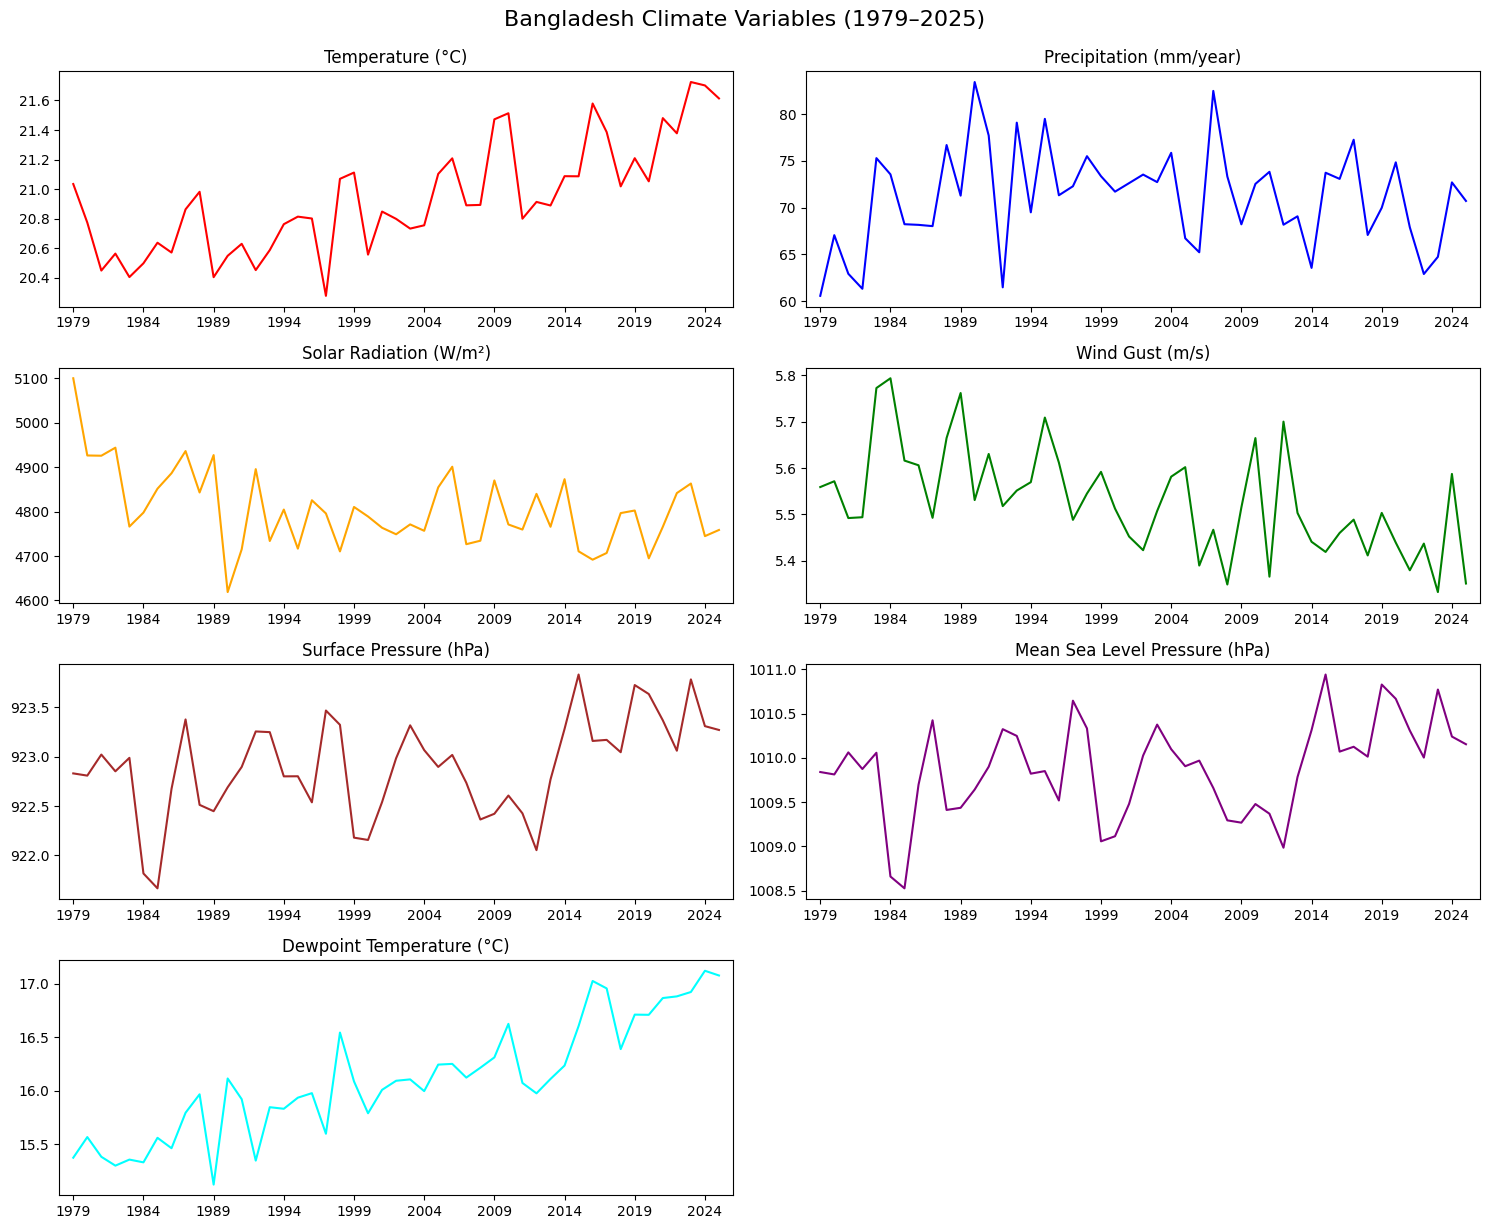

In [31]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15,12))

# Define tick spacing (every 5 years)
year_ticks = np.arange(1979, 2026, 5)

# Temperature
plt.subplot(4,2,1)
plt.plot(yearly_t2m.valid_time.dt.year, yearly_t2m, 'r')
plt.title("Temperature (°C)")
plt.xlim(1978, 2026)
plt.xticks(year_ticks)   # 5-year interval ticks
# plt.ylim(20, 42)       # optional

# Precipitation
plt.subplot(4,2,2)
plt.plot(yearly_tp.valid_time.dt.year, yearly_tp, 'b')
plt.title("Precipitation (mm/year)")
plt.xlim(1978, 2026)
plt.xticks(year_ticks)
# plt.ylim(0, 4000)

# Solar Radiation
plt.subplot(4,2,3)
plt.plot(yearly_ssrd.valid_time.dt.year, yearly_ssrd, 'orange')
plt.title("Solar Radiation (W/m²)")
plt.xlim(1978, 2026)
plt.xticks(year_ticks)

# Wind Gust
plt.subplot(4,2,4)
plt.plot(yearly_i10fg.valid_time.dt.year, yearly_i10fg, 'g')
plt.title("Wind Gust (m/s)")
plt.xlim(1978, 2026)
plt.xticks(year_ticks)

# Surface Pressure
plt.subplot(4,2,5)
plt.plot(yearly_sp.valid_time.dt.year, yearly_sp, 'brown')
plt.title("Surface Pressure (hPa)")
plt.xlim(1978, 2026)
plt.xticks(year_ticks)

# Mean Sea Level Pressure
plt.subplot(4,2,6)
plt.plot(yearly_msl.valid_time.dt.year, yearly_msl, 'purple')
plt.title("Mean Sea Level Pressure (hPa)")
plt.xlim(1978, 2026)
plt.xticks(year_ticks)

# Dewpoint Temperature
plt.subplot(4,2,7)
plt.plot(yearly_d2m.valid_time.dt.year, yearly_d2m, 'cyan')
plt.title("Dewpoint Temperature (°C)")
plt.xlim(1978, 2026)
plt.xticks(year_ticks)

plt.tight_layout()
plt.suptitle("Bangladesh Climate Variables (1979–2025)", fontsize=16, y=1.02)
plt.show()


/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/usr/local

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import os
print(os.listdir())   # বর্তমান folder এ সব ফাইল দেখাবে


['.config', 'era5_bangladesh_2006_2025.zip', 'era5_monthly_bangladesh_1979_2025.nc', 'era5_bangladesh_1991_2005_data_stream-moda_stepType-avgad.nc', 'era5_bangladesh_1979_1990.zip', 'era5_bangladesh_1979_1990_data_stream-moda_stepType-avgad.nc', 'era5_bangladesh_2006_2025_data_stream-moda_stepType-avgua.nc', 'era5_bangladesh_1991_2005.zip', 'era5_bangladesh_2006_2025_data_stream-moda_stepType-avgad.nc', 'drive', 'era5_bangladesh_2006_2025_data_stream-moda_stepType-avgid.nc', 'era5_bangladesh_1979_1990_data_stream-moda_stepType-avgua.nc', 'era5_bangladesh_1991_2005_data_stream-moda_stepType-avgid.nc', 'era5_bangladesh_1979_1990_data_stream-moda_stepType-avgid.nc', 'era5_bangladesh_1991_2005_data_stream-moda_stepType-avgua.nc', 'sample_data']


In [15]:
# Bangladesh region এর উপর spatial mean
ds_mean = ds.mean(dim=["latitude", "longitude"])

# প্রতি বছরের total precipitation (mm)
yearly_precip = ds_mean.tp.resample(time="1Y").sum() * 1000

plt.figure(figsize=(10,5))
plt.plot(yearly_precip.time.dt.year, yearly_precip, color="blue", label="Precipitation (mm)")
plt.title("ERA5 Bangladesh Annual Total Precipitation (1979–2025)")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm)")
plt.legend()
plt.grid(True)
plt.show()


KeyError: 'time'

/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


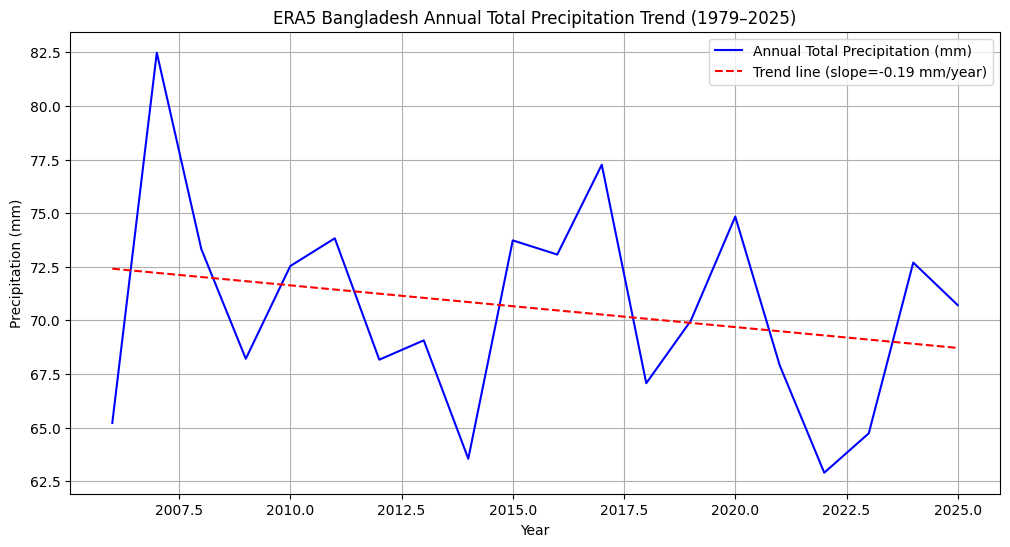

In [55]:
import zipfile
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# সব zip ফাইলের লিস্ট
zip_files = [
    "era5_bangladesh_1979_1990.zip",
    "era5_bangladesh_1991_2005.zip",
    "era5_bangladesh_2006_2025.zip"
]

# আনজিপ ফোল্ডার
extract_folder = "era5_data"
os.makedirs(extract_folder, exist_ok=True)

# প্রতিটি zip আনজিপ করো
for zf in zip_files:
    with zipfile.ZipFile(zf, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

# শুধু avgad ফাইলগুলো লিস্ট করো
avgad_files = glob.glob(os.path.join(extract_folder, "*avgad.nc"))

# merge করে dataset বানাও
ds = xr.open_mfdataset(avgad_files, combine='by_coords')

# valid_time থাকলে rename করো
if "valid_time" in ds.coords:
    ds = ds.rename({'valid_time': 'time'})

# Bangladesh region এর উপর spatial mean
ds_mean = ds.mean(dim=["latitude", "longitude"])

# প্রতি বছরের total precipitation (mm)
yearly_precip = ds_mean.tp.resample(time="1Y").sum() * 1000

# Trend analysis
years = yearly_precip.time.dt.year.values
precip_values = yearly_precip.values

# Linear regression (trend line)
coeffs = np.polyfit(years, precip_values, 1)
trend_line = np.polyval(coeffs, years)

# Plot
plt.figure(figsize=(12,6))
plt.plot(years, precip_values, 'b-', label="Annual Total Precipitation (mm)")
plt.plot(years, trend_line, 'r--', label=f"Trend line (slope={coeffs[0]:.2f} mm/year)")
plt.title("ERA5 Bangladesh Annual Total Precipitation Trend (1979–2025)")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm)")
plt.legend()
plt.grid(True)
plt.show()


**GEE**

In [ ]:

Map = gee.Map(basemap = "SATELLITE")
Map


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
import geemap

# Bangladesh centered
Map = geemap.Map(center=[23.7, 90.4], zoom=7, basemap="SATELLITE")
Map

Map(center=[23.7, 90.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [ ]:
roi = Map.user_roi
print(roi.getInfo())

{'geodesic': False, 'type': 'Polygon', 'coordinates': [[[85.345982, 18.479609], [85.345982, 28.536275], [95.542842, 28.536275], [95.542842, 18.479609], [85.345982, 18.479609]]]}


In [ ]:
import geemap
import ee

ee.Authenticate()
ee.Initialize(project='climate-data-analysis-01')

# ম্যাপ তৈরি করো
Map = geemap.Map(center=[22.8, 89.5], zoom=8, basemap="SATELLITE")

# ROI আঁকার টুল চালু করো
Map.add_draw_control()

# ম্যাপ দেখাও
Map


Map(center=[22.8, 89.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [ ]:
roi = Map.user_roi
print(roi.getInfo())


{'geodesic': False, 'type': 'Polygon', 'coordinates': [[[87.759024, 21.366129], [87.759024, 23.84565], [92.027861, 23.84565], [92.027861, 21.366129], [87.759024, 21.366129]]]}


In [ ]:
import ee
import geemap
import xarray as xr

ee.Authenticate()
ee.Initialize(project='climate-data-analysis-01')

# ERA5 dataset
collection = ee.ImageCollection("ECMWF/ERA5/MONTHLY") \
    .select('mean_2m_air_temperature') \
    .filterDate('1986-01-01', '2025-12-31')

# ROI (তুমি ম্যাপে এঁকেছো)
roi = Map.user_roi

# একটি sample image নাও
img = collection.first()

# ROI + scale দিয়ে numpy array বানাও
arr = geemap.ee_to_numpy(img, region=roi, scale=25000)

# numpy থেকে xarray বানাও
ds = xr.DataArray(
    arr.squeeze(),
    dims=["y", "x"]
)

print(ds)


<xarray.DataArray (y: 12, x: 20)> Size: 960B
array([[290.752  , 290.9773 , 290.8231 , 290.8231 , 290.92352, 291.0816 ,
        291.11816, 291.27457, 291.4931 , 291.66016, 291.69608, 291.67993,
        291.87384, 291.87384, 292.04117, 292.04803, 291.92953, 291.58316,
        291.5113 , 291.2817 ],
       [290.94858, 290.83258, 290.95517, 290.95517, 290.9597 , 291.07492,
        291.167  , 291.3064 , 291.73804, 292.33185, 291.96475, 291.9135 ,
        291.96222, 291.96222, 291.98016, 291.90793, 291.74722, 291.51306,
        291.46524, 291.07153],
       [290.9143 , 290.98367, 291.07196, 291.07196, 291.11786, 291.2163 ,
        291.34122, 291.43854, 291.60526, 291.8968 , 292.02396, 292.13837,
        292.20245, 292.20245, 292.16797, 292.02798, 291.8365 , 291.84506,
        291.97012, 291.29797],
       [291.05566, 291.14886, 291.2033 , 291.2033 , 291.3743 , 291.36887,
        291.53394, 291.63638, 291.77515, 291.90588, 291.92053, 292.14133,
        292.78717, 292.78717, 292.71597, 292.215

In [ ]:
arr = geemap.ee_to_numpy(img, region=roi, scale=25000)

# numpy থেকে xarray বানাও
ds = xr.DataArray(
    arr.squeeze(),
    dims=["y", "x"]
)

print(ds)

<xarray.DataArray (y: 12, x: 20)> Size: 960B
array([[290.752  , 290.9773 , 290.8231 , 290.8231 , 290.92352, 291.0816 ,
        291.11816, 291.27457, 291.4931 , 291.66016, 291.69608, 291.67993,
        291.87384, 291.87384, 292.04117, 292.04803, 291.92953, 291.58316,
        291.5113 , 291.2817 ],
       [290.94858, 290.83258, 290.95517, 290.95517, 290.9597 , 291.07492,
        291.167  , 291.3064 , 291.73804, 292.33185, 291.96475, 291.9135 ,
        291.96222, 291.96222, 291.98016, 291.90793, 291.74722, 291.51306,
        291.46524, 291.07153],
       [290.9143 , 290.98367, 291.07196, 291.07196, 291.11786, 291.2163 ,
        291.34122, 291.43854, 291.60526, 291.8968 , 292.02396, 292.13837,
        292.20245, 292.20245, 292.16797, 292.02798, 291.8365 , 291.84506,
        291.97012, 291.29797],
       [291.05566, 291.14886, 291.2033 , 291.2033 , 291.3743 , 291.36887,
        291.53394, 291.63638, 291.77515, 291.90588, 291.92053, 292.14133,
        292.78717, 292.78717, 292.71597, 292.215

In [ ]:
ds_celsius = ds - 273.15
print(ds_celsius)


<xarray.DataArray (y: 12, x: 20)> Size: 960B
array([[17.60202 , 17.827301, 17.673096, 17.673096, 17.77353 , 17.93161 ,
        17.96817 , 18.124573, 18.34311 , 18.510162, 18.546082, 18.529938,
        18.723846, 18.723846, 18.891174, 18.89804 , 18.779541, 18.433167,
        18.361298, 18.131714],
       [17.798584, 17.682587, 17.805176, 17.805176, 17.809692, 17.924927,
        18.016998, 18.156403, 18.588043, 19.181854, 18.814758, 18.76352 ,
        18.812225, 18.812225, 18.83017 , 18.757935, 18.597229, 18.363068,
        18.315247, 17.92154 ],
       [17.764313, 17.83368 , 17.921967, 17.921967, 17.967865, 18.066315,
        18.191223, 18.288544, 18.455261, 18.746796, 18.873962, 18.988373,
        19.05246 , 19.05246 , 19.017975, 18.87799 , 18.686493, 18.695068,
        18.82013 , 18.14798 ],
       [17.90567 , 17.99887 , 18.053314, 18.053314, 18.224304, 18.218872,
        18.383942, 18.48639 , 18.625153, 18.75589 , 18.770538, 18.991333,
        19.637177, 19.637177, 19.565979, 19.0654

In [ ]:

print(ds.dims)       # dimension নাম ও size
print(ds.shape)      # array এর আকার (rows, cols)
print(ds.dtype)      # data type (float32 ইত্যাদি)


('y', 'x')
(12, 20)
float32


In [ ]:
import ee, geemap, xarray as xr, numpy as np, pandas as pd

ee.Authenticate()
ee.Initialize(project='climate-data-analysis-01')

# ERA5 dataset থেকে 2020 সালের মাসিক temperature নাও
collection = ee.ImageCollection("ECMWF/ERA5/MONTHLY") \
    .select('mean_2m_air_temperature') \
    .filterDate('2020-01-01', '2020-12-31')

roi = Map.user_roi

# সব image লিস্টে নাও
images = collection.toList(collection.size())
n = collection.size().getInfo()

arrays = []
times = []

for i in range(n):
    img = ee.Image(images.get(i))
    date = img.date().format("YYYY-MM-dd").getInfo()
    arr = geemap.ee_to_numpy(img, region=roi, scale=25000)
    arrays.append(arr.squeeze())
    times.append(pd.to_datetime(date))

# numpy stack → (time, y, x)
data = np.stack(arrays)

# xarray বানাও
ds = xr.DataArray(
    data,
    dims=["time","y","x"],
    coords={"time": times}
)

print(ds)


<xarray.DataArray (time: 6, y: 12, x: 20)> Size: 6kB
array([[[290.472  , 290.6016 , 290.3857 , ..., 290.49753, 290.61548,
         290.56046],
        [290.79132, 290.65033, 290.54587, ..., 290.55524, 290.61838,
         290.56363],
        [290.77307, 290.7166 , 290.69724, ..., 290.83893, 291.18103,
         290.94272],
        ...,
        [292.21298, 292.43625, 292.1645 , ..., 293.35394, 293.51788,
         292.71124],
        [292.6288 , 292.93674, 292.74396, ..., 293.6934 , 293.89316,
         293.05545],
        [293.38986, 293.37643, 293.346  , ..., 294.16006, 294.2704 ,
         293.26657]],

       [[292.65158, 292.8672 , 292.6797 , ..., 293.025  , 293.06314,
         292.77066],
        [293.05618, 292.9337 , 292.9198 , ..., 293.10574, 293.037  ,
         292.84302],
        [293.1065 , 293.04257, 293.00885, ..., 293.24475, 293.11978,
         292.92624],
...
        [302.4663 , 302.30304, 302.2653 , ..., 301.5736 , 301.51782,
         301.62854],
        [302.28244, 301.8252

In [ ]:
annual = ds.resample(time="YE").mean("time")
print(annual)


<xarray.DataArray (time: 1, y: 12, x: 20)> Size: 960B
array([[[297.8819 , 297.9827 , 297.76852, 297.76852, 297.71085,
         297.68222, 297.54288, 297.52957, 297.59183, 297.64255,
         297.53714, 297.4075 , 297.48108, 297.48108, 297.5198 ,
         297.49963, 297.4801 , 297.25656, 297.0754 , 296.91592],
        [298.26822, 298.12247, 298.03043, 298.03043, 297.83463,
         297.7628 , 297.73978, 297.7415 , 297.8862 , 298.14188,
         297.99725, 297.74454, 297.62833, 297.62833, 297.59888,
         297.58908, 297.5529 , 297.48453, 297.157  , 296.99756],
        [298.3014 , 298.2027 , 298.16525, 298.16525, 298.0911 ,
         297.90604, 297.85294, 297.79358, 297.777  , 297.90872,
         298.0666 , 298.04575, 297.96304, 297.96304, 297.85303,
         297.76205, 297.70703, 297.71664, 297.3119 , 297.14563],
        [298.50937, 298.3773 , 298.26077, 298.26077, 298.249  ,
         298.0022 , 297.94727, 297.90408, 297.90298, 297.9578 ,
         297.8996 , 298.0483 , 298.3871 , 298.3

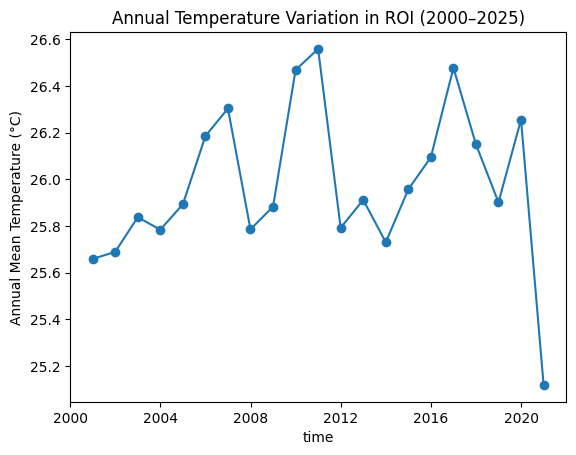

In [ ]:
import ee, geemap, xarray as xr, numpy as np, pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='climate-data-analysis-01')

# ERA5 dataset থেকে 2000–2025 সালের মাসিক temperature নাও
collection = ee.ImageCollection("ECMWF/ERA5/MONTHLY") \
    .select('mean_2m_air_temperature') \
    .filterDate('2000-01-01', '2025-12-31')

roi = Map.user_roi

# সব image লিস্টে নাও
images = collection.toList(collection.size())
n = collection.size().getInfo()

arrays = []
times = []

for i in range(n):
    img = ee.Image(images.get(i))
    date = img.date().format("YYYY-MM-dd").getInfo()
    arr = geemap.ee_to_numpy(img, region=roi, scale=25000)
    arrays.append(arr.squeeze())
    times.append(pd.to_datetime(date))

# numpy stack → (time, y, x)
data = np.stack(arrays)

# xarray বানাও
ds = xr.DataArray(
    data,
    dims=["time","y","x"],
    coords={"time": times}
)

# বার্ষিক গড় বের করো
annual = ds.resample(time="YE").mean("time")

# ROI এর উপর spatial mean নাও
roi_mean = annual.mean(dim=["y","x"]) - 273.15   # Celsius এ রূপান্তর

# টাইম সিরিজ প্লট করো
roi_mean.plot(marker="o")
plt.ylabel("Annual Mean Temperature (°C)")
plt.title("Annual Temperature Variation in ROI (2000–2025)")
plt.show()


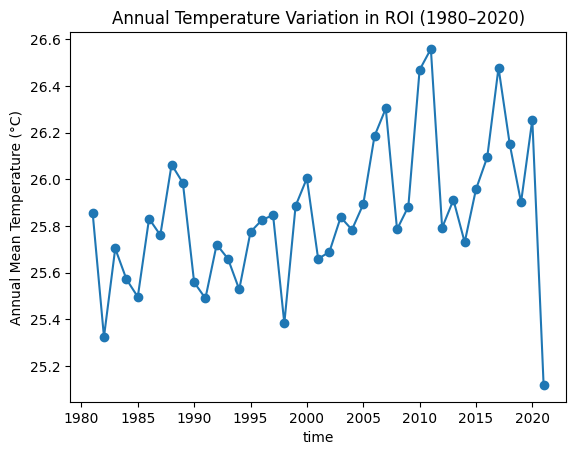

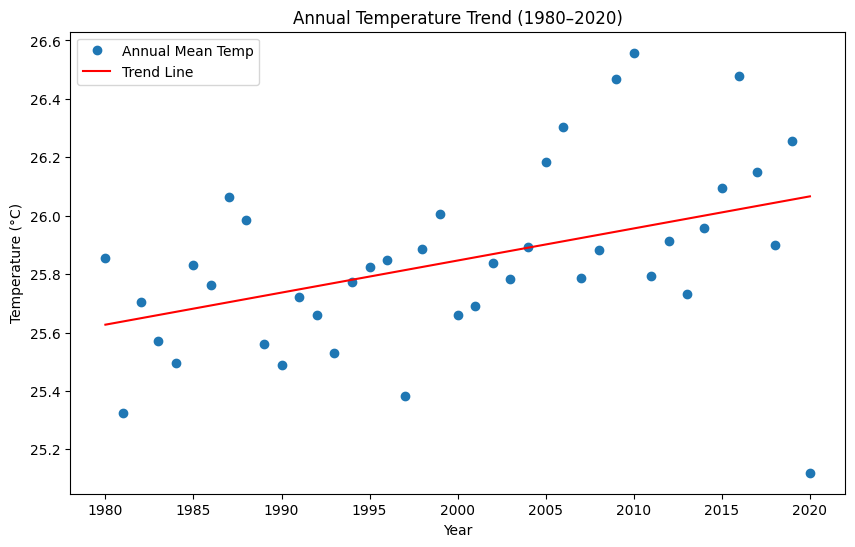

In [ ]:
import ee, geemap, xarray as xr, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Authenticate & Initialize Earth Engine
ee.Authenticate()
ee.Initialize(project='climate-data-analysis-01')

# ERA5 dataset থেকে 1980–2020 সালের মাসিক temperature নাও
collection = ee.ImageCollection("ECMWF/ERA5/MONTHLY") \
    .select('mean_2m_air_temperature') \
    .filterDate('1980-01-01', '2020-12-31')

# ROI (Khulna বা Barishal region polygon)
roi = Map.user_roi   # Map এ আঁকা ROI ব্যবহার করো

# সব image লিস্টে নাও
images = collection.toList(collection.size())
n = collection.size().getInfo()

arrays = []
times = []

for i in range(n):
    img = ee.Image(images.get(i))
    date = img.date().format("YYYY-MM-dd").getInfo()
    arr = geemap.ee_to_numpy(img, region=roi, scale=25000)
    arrays.append(arr.squeeze())
    times.append(pd.to_datetime(date))

# numpy stack → (time, y, x)
data = np.stack(arrays)

# xarray বানাও
ds = xr.DataArray(
    data,
    dims=["time","y","x"],
    coords={"time": times}
)

# বার্ষিক গড় বের করো
annual = ds.resample(time="YE").mean("time")

# ROI এর উপর spatial mean নাও এবং Celsius এ রূপান্তর করো
roi_mean = annual.mean(dim=["y","x"]) - 273.15

# টাইম সিরিজ প্লট করো
roi_mean.plot(marker="o")
plt.ylabel("Annual Mean Temperature (°C)")
plt.title("Annual Temperature Variation in ROI (1980–2020)")
plt.show()

# 🔧 Trend line যোগ করো (linear regression)
years = roi_mean.time.dt.year.values
temps = roi_mean.values
X = sm.add_constant(years)
model = sm.OLS(temps, X).fit()
trend = model.predict(X)

plt.figure(figsize=(10,6))
plt.plot(years, temps, 'o', label="Annual Mean Temp")
plt.plot(years, trend, '-', label="Trend Line", color="red")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Annual Temperature Trend (1980–2020)")
plt.legend()
plt.show()


In [ ]:
import ee, geemap, xarray as xr, numpy as np, pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='climate-data-analysis-01')

# একসাথে সব variables select করো
collection = ee.ImageCollection("ECMWF/ERA5/MONTHLY") \
    .select([
        'mean_2m_air_temperature',          # T2M
        'total_precipitation',              # TP
        'dewpoint_temperature_2m',          # D2M (RH এর জন্য)
        'surface_solar_radiation_downwards',# SSRD
        'mean_surface_wind_speed'           # WG10 (approx gust)
    ]) \
    .filterDate('1975-01-01', '2025-12-31')

roi = Map.user_roi

images = collection.toList(collection.size())
n = collection.size().getInfo()

arrays, times = [], []
for i in range(n):
    img = ee.Image(images.get(i))
    date = img.date().format("YYYY-MM-dd").getInfo()
    arr = geemap.ee_to_numpy(img, region=roi, scale=25000)
    arrays.append(arr)
    times.append(pd.to_datetime(date))

# numpy stack → (time, variable, y, x)
data = np.stack(arrays)

# Xarray বানাও
ds = xr.DataArray(
    data,
    dims=["time","variable","y","x"],
    coords={"time": times,
            "variable": ['T2M','TP','D2M','SSRD','WG10']}
)

# Relative Humidity derive করো
T = ds.sel(variable="T2M") - 273.15
Td = ds.sel(variable="D2M") - 273.15
RH = 100 * (np.exp((17.625*Td)/(243.04+Td)) / np.exp((17.625*T)/(243.04+T)))

# RH কে dataset এ যোগ করো
ds = xr.concat([ds, RH.expand_dims("variable").assign_coords(variable=["RH"])], dim="variable")

# বার্ষিক গড় বের করো
annual = ds.resample(time="YE").mean("time")

# ROI mean বের করো
roi_mean = annual.mean(dim=["y","x"])

# Multi-panel plot
fig, axes = plt.subplots(3,2, figsize=(12,10))
variables = ["T2M","TP","RH","SSRD","WG10"]
for ax, var in zip(axes.flat, variables):
    roi_mean.sel(variable=var).plot(marker="o", ax=ax)
    ax.set_title(f"Annual {var} (1975–2025)")
plt.tight_layout()
plt.show()


MessageError: Error: credential propagation was unsuccessful